# Классификация новостей Lenta.ru по категориям
**Задача:** Многоклассовая классификация текстов новостей по тематическим категориям

In [1]:
import gc
import os
import joblib
import wordcloud
import requests
import pandas as pd
import numpy as np
import os.path as path
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

from bs4 import BeautifulSoup
from tqdm import tqdm
from collections import Counter

# NLP
import re
import nltk
import pymorphy3
from nltk.corpus import stopwords

# ML
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.metrics import (
    classification_report, accuracy_score,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.calibration import CalibratedClassifierCV

# Utils
from IPython.core.ultratb import AutoFormattedTB
from pandarallel import pandarallel

tqdm.pandas()
pandarallel.initialize(progress_bar=True)
nltk.download('stopwords', quiet=True)
plt.rcParams['figure.dpi'] = 100

INFO: Pandarallel will run on 6 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.


/home/yaekitsune/Projects/MOiBD_Russian_news_group_project/.venv/lib/python3.14/site-packages/nltk/downloader.py:980: RuntimeWarning: Security Violation [pathsec.urlopen]: SSRF attempt to restricted IP 198.18.0.85
  ElementTree.parse(urlopen(self._url)).getroot()


In [2]:
itb = AutoFormattedTB(mode='Plain', tb_offset=1)

def custom_exc(shell, etype, evalue, tb, tb_offset=None):
    stb = itb.structured_traceback(etype, evalue, tb)
    print("\n" + "─"*50)
    print("КРИТИЧЕСКАЯ ОШИБКА: ОБРАБОТКА ПРЕРВАНА\n")
    print(itb.stb2text(stb))
    print("─"*50)

get_ipython().set_custom_exc((Exception,), custom_exc)

In [3]:
BASEPATH = ".."
RESOURCES = f"{BASEPATH}/Resource"
MODELS_DIR = f"{BASEPATH}/Models"
EXT = "pkl" 

# set вместо list — поиск O(1)
RUSSIAN_STOP_WORDS = set(stopwords.words('russian'))
RUSSIAN_STOP_WORDS.update({
    'также', 'однако', 'который', 'это', 'собственный', 'сообщать', 'заявить',
    'ранее', 'свой', 'весь', 'мочь', 'стать', 'время', 'год', 'слово', 'новость',
    'отметить', 'рассказать', 'получить', 'являться', 'назвать', 'говорить',
    'частности', 'именно', 'поскольку', 'кроме', 'находиться', 'сообщается',
    'российский', 'россия', 'рф', 'москва'
})

---
# 1. Определение структуры набора данных и анализ атрибутов

## 1.1 Загрузка данных

In [ ]:
if not path.isdir(RESOURCES):
    raise NotADirectoryError(f"Директория '{RESOURCES}' не найдена. Выполните 'git pull' или создайте папку согласно README.md")

if not path.isfile(f"{RESOURCES}/lenta-ru-news.csv"):
    raise FileNotFoundError("Файл lenta-ru-news.csv не найден. Загрузите датасет согласно README.md")

NEEDED_COLS = ['title', 'text', 'topic', 'date']

try:
    if path.isfile(f"{RESOURCES}/database.parquet"):
        DataBase = pd.read_parquet(f"{RESOURCES}/database.parquet")
        if 'date' not in DataBase.columns:
            DataBase = pd.read_csv(f"{RESOURCES}/lenta-ru-news.csv", usecols=NEEDED_COLS, low_memory=False)
            DataBase.to_parquet(f"{RESOURCES}/database.parquet")
    else:
        DataBase = pd.read_csv(f"{RESOURCES}/lenta-ru-news.csv", usecols=NEEDED_COLS, low_memory=False)
        DataBase.to_parquet(f"{RESOURCES}/database.parquet")

    print("─"*50)
    print("База данных инициализирована".center(50))
    print("─"*50)
    print(f"Строк: {len(DataBase):,}")
    print(f"Колонки: {list(DataBase.columns)}")
    print(f"Размер в памяти: {DataBase.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
except Exception as e:
    raise RuntimeError(f"Ошибка загрузки: {e}")

──────────────────────────────────────────────────
           База данных инициализирована           
──────────────────────────────────────────────────
Строк: 800,975
Колонки: ['title', 'text', 'topic', 'date']
Размер в памяти: 1964.3 MB


In [5]:
DataBase.head(10)

,title,text,topic,date
0,1914. Русские войска вступили в пределы Венгрии,Бои у Сопоцкина и Друскеник закончились отступ...,Библиотека,1914/09/16
1,1914. Празднование столетия М.Ю. Лермонтова от...,"Министерство народного просвещения, в виду про...",Библиотека,1914/09/16
2,1914. Das ist Nesteroff!,"Штабс-капитан П. Н. Нестеров на днях, увидев в...",Библиотека,1914/09/17
3,1914. Бульдог-гонец под Льежем,Фотограф-корреспондент Daily Mirror рассказыва...,Библиотека,1914/09/17
4,1914. Под Люблином пойман швабский зверь,"Лица, приехавшие в Варшаву из Люблина, передаю...",Библиотека,1914/09/18
5,"Космонавты сомневаются в надежности ""Мира""",Как стало известно агентству Ассошиэйтед Пресс...,Россия,1999/08/31
6,Взрыв в центре Москвы: пострадало 30 человек,В зале игровых автоматов в третьем ярусе подзе...,Россия,1999/08/31
7,Япония кредитует Россию на полтора миллиарда д...,Япония приняла решение разморозить кредиты Рос...,Россия,1999/08/31
8,Британцы отмечают двухлетие смерти Дианы,Британцы отмечают сегодня скорбную дату - втор...,Мир,1999/08/31
9,Отмытые через Bank of NY деньги не имели отнош...,В понедельник директор департамента внешних св...,Россия,1999/08/31


## 1.2 Исследовательский анализ данных (EDA)

Перед выбором признаков проведём детальный анализ структуры датасета:
- Распределение по категориям (балансировка классов)
- Статистика длин текстов
- Динамика публикаций по времени
- Качество данных (пропуски, дубликаты)

In [6]:
print("=" * 50)
print("ОБЩАЯ СТАТИСТИКА ДАТАСЕТА")
print("=" * 50)
print(f"Всего записей:        {len(DataBase):>10,}")
print(f"Уникальных категорий: {DataBase['topic'].nunique():>10,}")
print(f"Пропуски в topic:     {DataBase['topic'].isna().sum():>10,}")
print(f"Пропуски в text:      {DataBase['text'].isna().sum():>10,}")
print(f"Дубликатов (текст):   {DataBase.duplicated(subset=['text']).sum():>10,}")
print()
DataBase.describe(include='all')

ОБЩАЯ СТАТИСТИКА ДАТАСЕТА
Всего записей:           800,975
Уникальных категорий:         23
Пропуски в topic:         62,002
Пропуски в text:               5
Дубликатов (текст):          937



,title,text,topic,date
count,800975,800970,738973,800975
unique,797832,800037,23,7393
top,В Москве объявлено штормовое предупреждение,"РИА ""Новости""",Россия,2019/12/05
freq,21,291,160445,284


Распределение новостей по категориям:
                   Количество  Доля (%)
topic                                  
Россия                 160445     21.71
Мир                    136621     18.49
Экономика               79528     10.76
Спорт                   64413      8.72
Культура                53797      7.28
Бывший СССР             53402      7.23
Наука и техника         53136      7.19
Интернет и СМИ          44663      6.04
Из жизни                27605      3.74
Дом                     21734      2.94
Силовые структуры       19596      2.65
Ценности                 7766      1.05
Бизнес                   7399      1.00
Путешествия              6408      0.87
69-я параллель           1268      0.17
Крым                      666      0.09
Культпросвет              340      0.05
Легпром                   114      0.02
Библиотека                 65      0.01
Оружие                      3      0.00
ЧМ-2014                     2      0.00
Сочи                        1      0.00
Ме

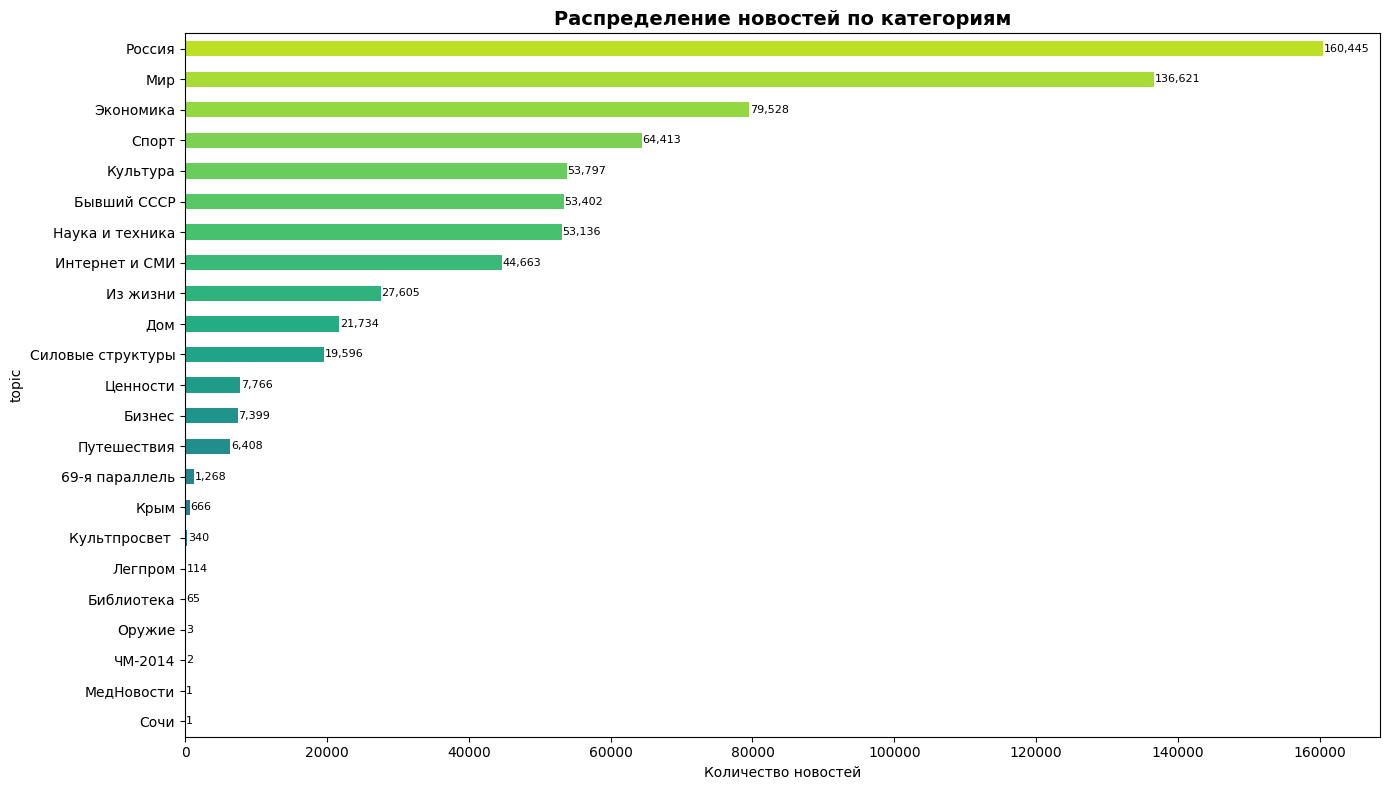

In [7]:
# Распределение по категориям
topic_counts = DataBase['topic'].value_counts()
topic_pct = DataBase['topic'].value_counts(normalize=True) * 100

topic_stats = pd.DataFrame({
    'Количество': topic_counts,
    'Доля (%)': topic_pct.round(2)
})
print("Распределение новостей по категориям:")
print(topic_stats.to_string())

fig, ax = plt.subplots(figsize=(14, 8))
colors = cm.viridis(np.linspace(0.2, 0.9, len(topic_counts)))
topic_counts.sort_values().plot(kind='barh', ax=ax, color=colors)
ax.set_title('Распределение новостей по категориям', fontsize=14, fontweight='bold')
ax.set_xlabel('Количество новостей')
for i, v in enumerate(topic_counts.sort_values()):
    ax.text(v + 100, i, f'{v:,}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

Статистика длин текстов (символы):
count    800975.0
mean       1389.0
std         550.0
min          29.0
25%        1033.0
50%        1311.0
75%        1657.0
max       55443.0
dtype: float64

Статистика длин текстов (слова):
count    800975.0
mean        188.0
std          74.0
min           4.0
25%         140.0
50%         178.0
75%         224.0
max        8096.0
dtype: float64


/tmp/ipykernel_22749/3458882400.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1,1].boxplot(data_box, labels=[t[:12] for t in top10], vert=False)


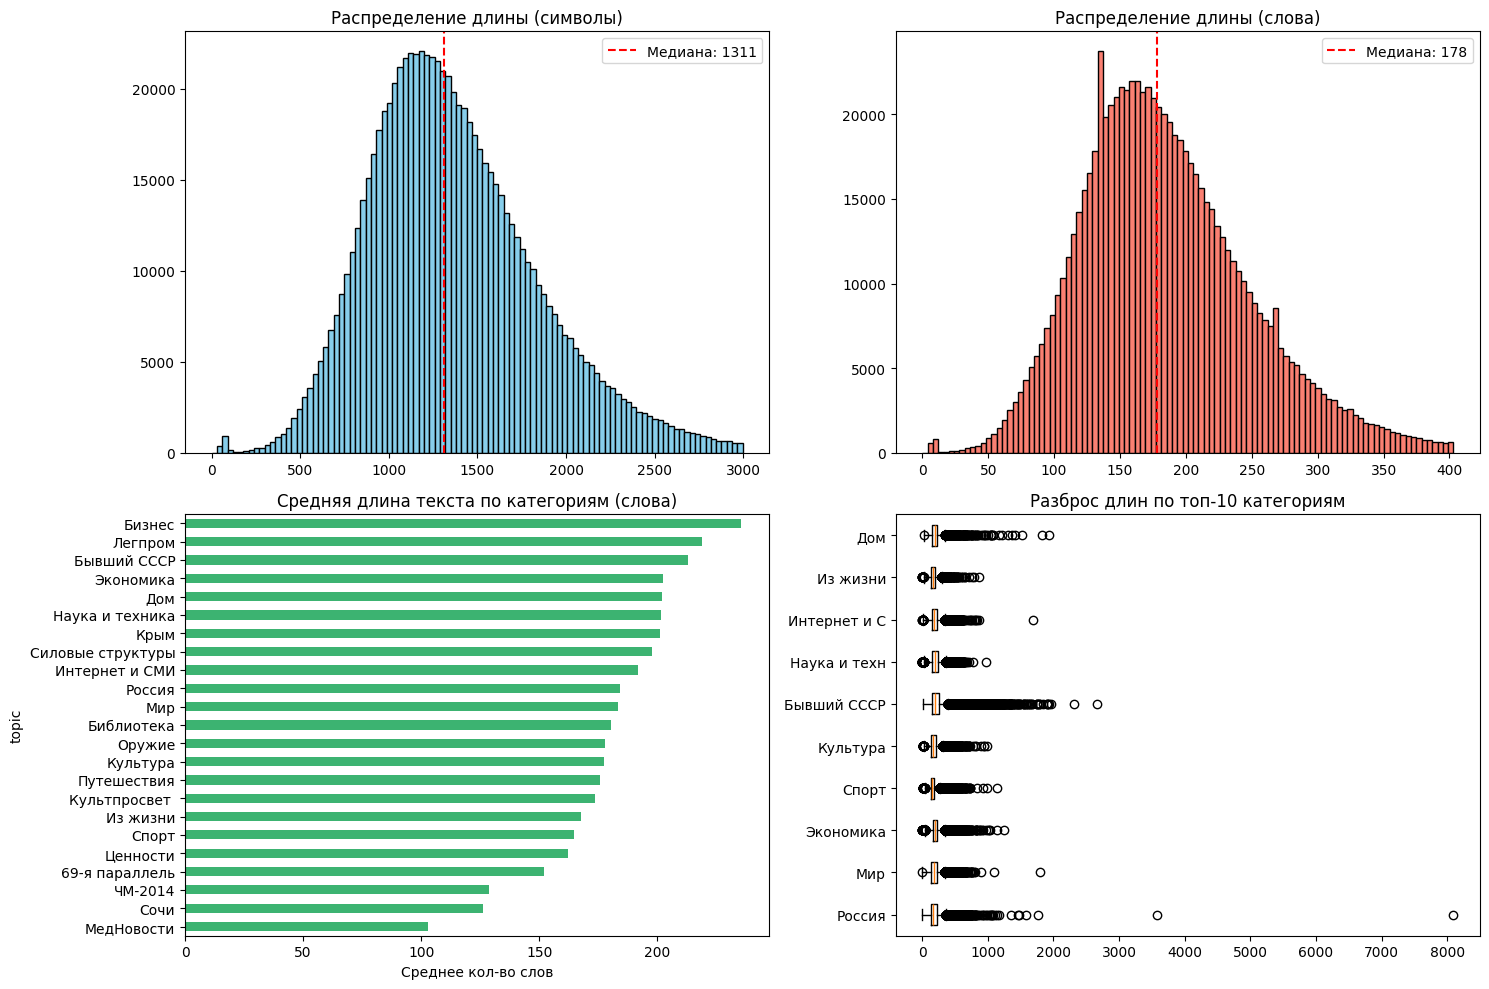

4

In [8]:
full_text = DataBase['title'].fillna('') + ' ' + DataBase['text'].fillna('')
len_chars = full_text.str.len()
len_words = full_text.str.split().str.len()

print("Статистика длин текстов (символы):")
print(len_chars.describe().round(0))
print("\nСтатистика длин текстов (слова):")
print(len_words.describe().round(0))

limit_chars = len_chars.quantile(0.99)
limit_words = len_words.quantile(0.99)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0,0].hist(len_chars, bins=100, range=(0, limit_chars), color='skyblue', edgecolor='black')
axes[0,0].set_title('Распределение длины (символы)')
axes[0,0].axvline(len_chars.median(), color='red', linestyle='--', label=f'Медиана: {len_chars.median():.0f}')
axes[0,0].legend()

axes[0,1].hist(len_words, bins=100, range=(0, limit_words), color='salmon', edgecolor='black')
axes[0,1].set_title('Распределение длины (слова)')
axes[0,1].axvline(len_words.median(), color='red', linestyle='--', label=f'Медиана: {len_words.median():.0f}')
axes[0,1].legend()

# Средняя длина по категориям
DataBase['len_words_tmp'] = len_words
avg_by_topic = DataBase.groupby('topic')['len_words_tmp'].mean().sort_values()
avg_by_topic.plot(kind='barh', ax=axes[1,0], color='mediumseagreen')
axes[1,0].set_title('Средняя длина текста по категориям (слова)')
axes[1,0].set_xlabel('Среднее кол-во слов')

# Box plot по топ-10 категориям
top10 = topic_counts.head(10).index
data_box = [DataBase[DataBase['topic']==t]['len_words_tmp'].dropna().values for t in top10]
axes[1,1].boxplot(data_box, labels=[t[:12] for t in top10], vert=False)
axes[1,1].set_title('Разброс длин по топ-10 категориям')

plt.tight_layout()
plt.show()

DataBase.drop(columns=['len_words_tmp'], inplace=True)
del full_text, len_chars, len_words, data_box
gc.collect()

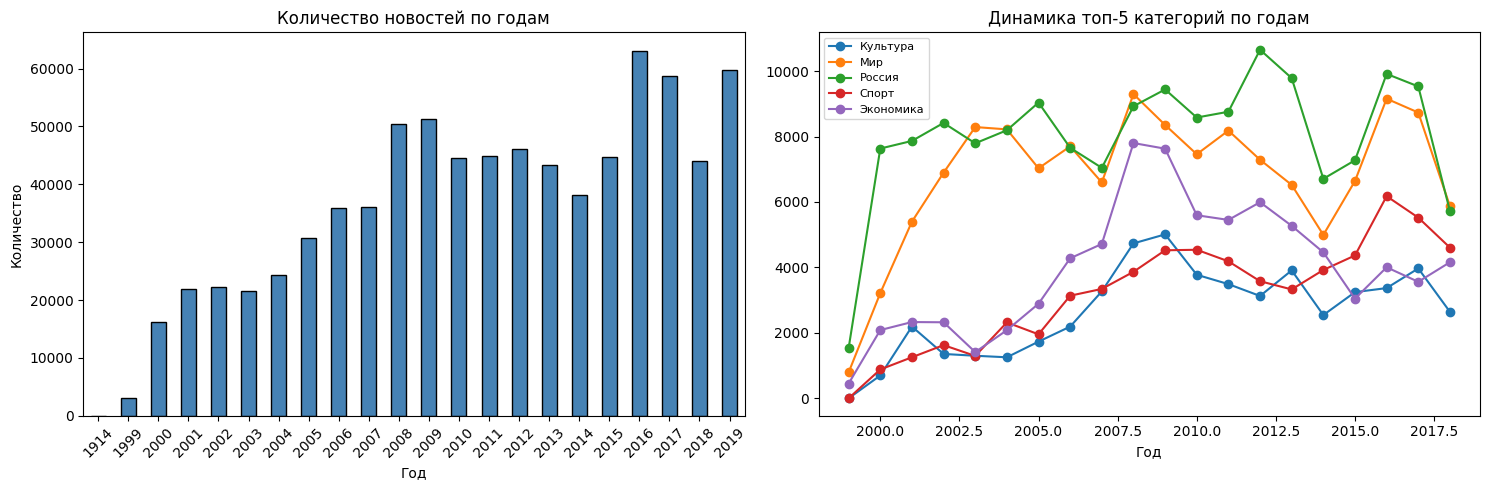

In [9]:
try:
    DataBase['year'] = pd.to_datetime(DataBase['date'], errors='coerce').dt.year
    year_counts = DataBase['year'].value_counts().sort_index()

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    year_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
    axes[0].set_title('Количество новостей по годам')
    axes[0].set_xlabel('Год')
    axes[0].set_ylabel('Количество')
    axes[0].tick_params(axis='x', rotation=45)

    top5_topics = topic_counts.head(5).index
    pivot = DataBase[DataBase['topic'].isin(top5_topics)].groupby(['year','topic']).size().unstack(fill_value=0)
    pivot.plot(ax=axes[1], marker='o')
    axes[1].set_title('Динамика топ-5 категорий по годам')
    axes[1].set_xlabel('Год')
    axes[1].legend(loc='upper left', fontsize=8)

    plt.tight_layout()
    plt.show()

    DataBase.drop(columns=['year'], inplace=True)
    del pivot
    gc.collect()
except Exception as e:
    print(f"Анализ по времени недоступен: {e}")

## 1.3 Обоснование выбора атрибутов

На основе EDA принято решение об использовании следующих атрибутов:

**Выбранные атрибуты:**

1. **text + title** (объединяются в один признак): Основной источник информации для классификации. Заголовки содержат сжатую суть статьи и часто являются наиболее информативными. Объединение заголовка с текстом увеличивает точность классификатора.
2. **topic**: Целевая переменная — категория новости.

**Исключённые атрибуты:**

1. **url**: Техническая ссылка, не несёт лингвистической информации для классификации.
2. **date**: Дата публикации не влияет на тематику текста. Использована только для EDA (анализ динамики), после чего удалена.
3. **tags**: Теги дублируют `topic` или содержат шумовые значения («Все»).

**Фильтрация категорий:** Категории с долей менее 0.5% от общего объёма исключены как статистически незначимые — слишком мало примеров для надёжного обучения классификатора.

**Обработка дисбаланса:** Датасет имеет значительный дисбаланс классов. Это учтено при обучении через параметр `class_weight='balanced'` в моделях.

In [10]:
DataBase['text'] = DataBase['title'].fillna('') + ' ' + DataBase['text'].fillna('')
DataBase.drop(columns=['title', 'date'], inplace=True, errors='ignore')
DataBase.drop_duplicates(subset=['text'], inplace=True)
DataBase.dropna(subset=['text', 'topic'], inplace=True)

print(f"После очистки: {len(DataBase):,} записей")
gc.collect()

После очистки: 738,951 записей


0

---
# 2. Предварительная обработка текстов

Этапы обработки:
1. Приведение к нижнему регистру
2. Удаление спецсимволов, цифр, лишних пробелов
3. Удаление стоп-слов (NLTK + расширенный список)
4. Лемматизация (pymorphy3 с кэшированием)

In [11]:
morph = pymorphy3.MorphAnalyzer()
cache = {}

def clean_and_lemmatize(text):
    if not isinstance(text, str): return ''
    # Нижний регистр + только буквы (рус/англ)
    words = re.findall(r'[а-яёa-z]+', text.lower())
    result = []
    for w in words:
        if w in RUSSIAN_STOP_WORDS or len(w) < 3:
            continue
        if w not in cache:
            cache[w] = morph.parse(w)[0].normal_form
        lemma = cache[w]
        if lemma not in RUSSIAN_STOP_WORDS and len(lemma) >= 3:
            result.append(lemma)
    return ' '.join(result)

In [12]:
if path.isfile(f"{RESOURCES}/database_lemmatized.parquet"):
    DataBaseLem = pd.read_parquet(f"{RESOURCES}/database_lemmatized.parquet")
    print(f"Загружен кэш лемматизации: {len(DataBaseLem):,} записей")
else:
    print("Запуск лемматизации (займёт ~10-20 мин на 800к строк)...")
    DataBaseLem = DataBase[['text', 'topic']].copy()
    DataBaseLem['text'] = DataBaseLem['text'].parallel_apply(clean_and_lemmatize)
    DataBaseLem.to_parquet(f"{RESOURCES}/database_lemmatized.parquet")
    print("Лемматизация завершена, сохранено в parquet")

del DataBase
gc.collect()

print(f"Размер в памяти: {DataBaseLem.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
DataBaseLem.head(3)

Загружен кэш лемматизации: 738,951 записей
Размер в памяти: 1428.6 MB


,text,topic
0,русский войско вступить предел венгрия бой соп...,Библиотека
1,празднование столетие лермонтов отложить минис...,Библиотека
2,das ist nesteroff штабс капитан нестеров день ...,Библиотека


In [13]:
# Пример обработки
sample_raw = "Российские военные нанесли удар по инфраструктуре Украины в ночь на пятницу"
sample_lem = clean_and_lemmatize(sample_raw)
print(f"Исходный текст:\n  {sample_raw}")
print(f"После обработки:\n  {sample_lem}")

Исходный текст:
  Российские военные нанесли удар по инфраструктуре Украины в ночь на пятницу
После обработки:
  военный нанести удар инфраструктура украина ночь пятница


---
# 3. Тематическое моделирование по категориям

## 3.1 Подготовка данных — фильтрация категорий

In [14]:
topic_pct = DataBaseLem['topic'].value_counts(normalize=True) * 100
THRESHOLD = 0.5  
main_topics = topic_pct[topic_pct >= THRESHOLD].index.tolist()
N_TOPICS = len(main_topics)

df_work = DataBaseLem[DataBaseLem['topic'].isin(main_topics)].copy()

print(f"Оставлено категорий: {N_TOPICS} (порог >= {THRESHOLD}%)")
print(f"Исключено категорий: {DataBaseLem['topic'].nunique() - N_TOPICS}")
print(f"Записей в работе:    {len(df_work):,}")
print(f"\nКатегории: {main_topics}")

Оставлено категорий: 14 (порог >= 0.5%)
Исключено категорий: 9
Записей в работе:    736,492

Категории: ['Россия', 'Мир', 'Экономика', 'Спорт', 'Культура', 'Бывший СССР', 'Наука и техника', 'Интернет и СМИ', 'Из жизни', 'Дом', 'Силовые структуры', 'Ценности', 'Бизнес', 'Путешествия']


## 3.2 Облака слов по категориям

Генерация облаков слов для 14 категорий...


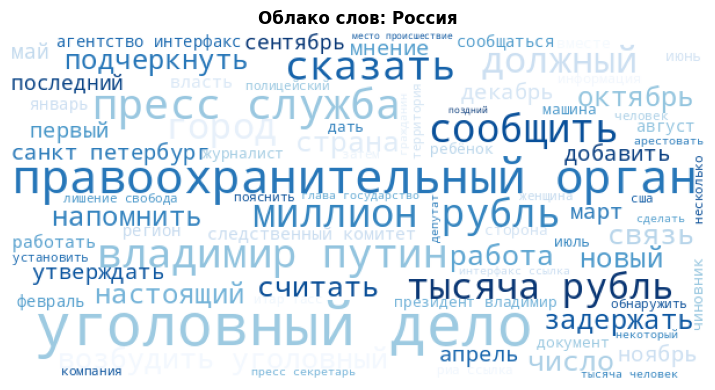

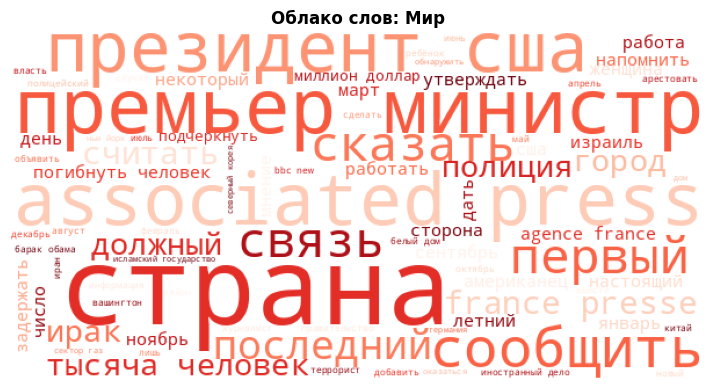

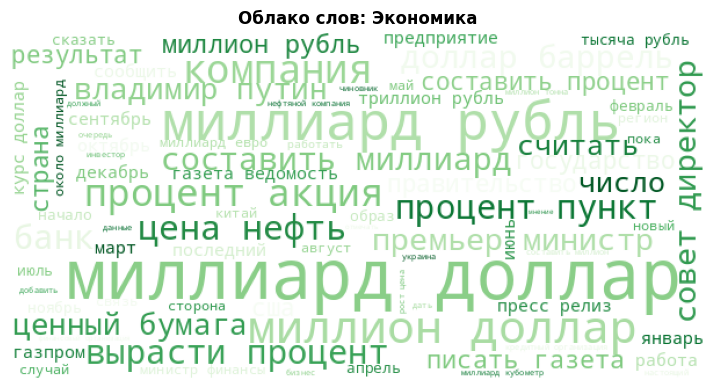

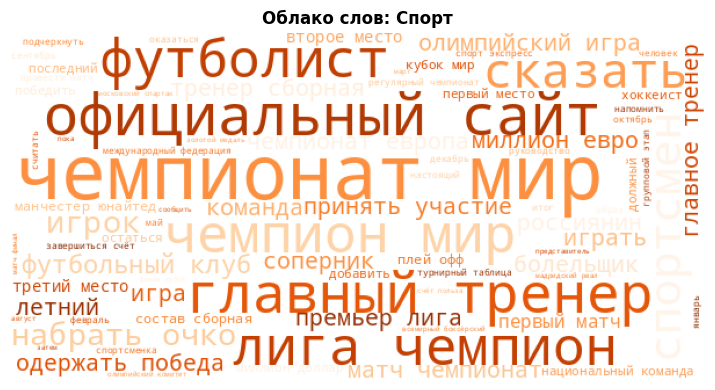

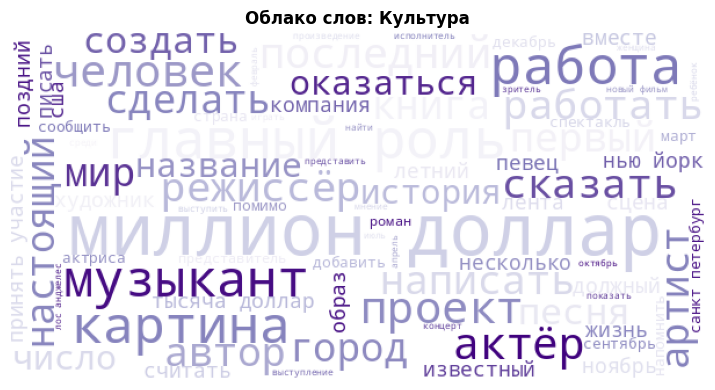

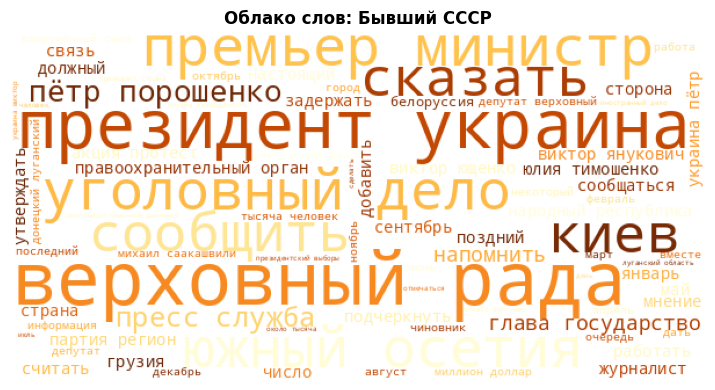

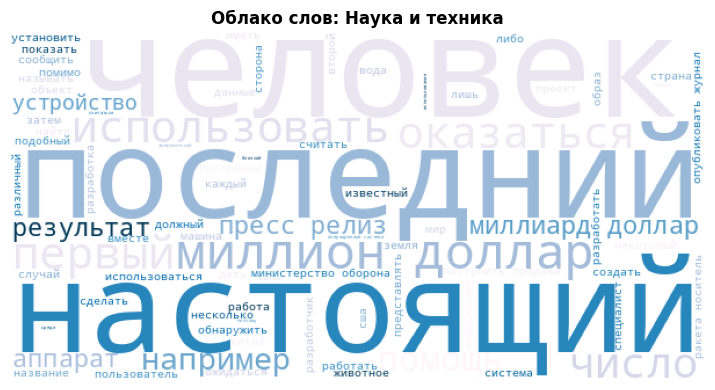

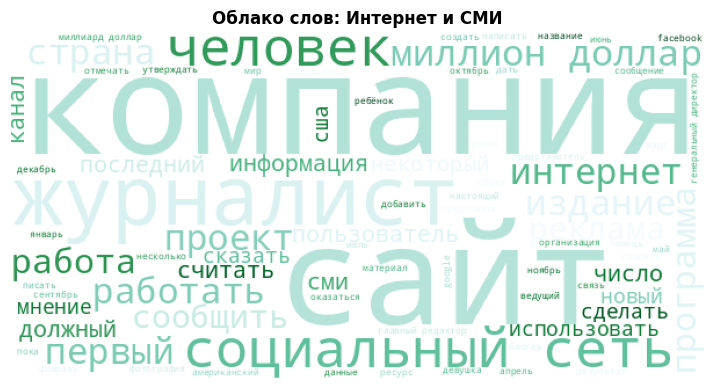

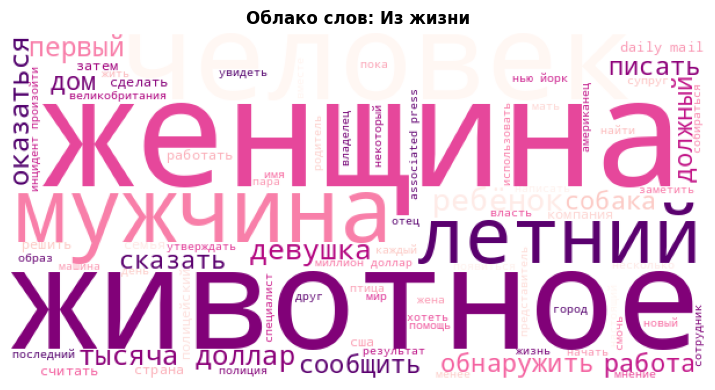

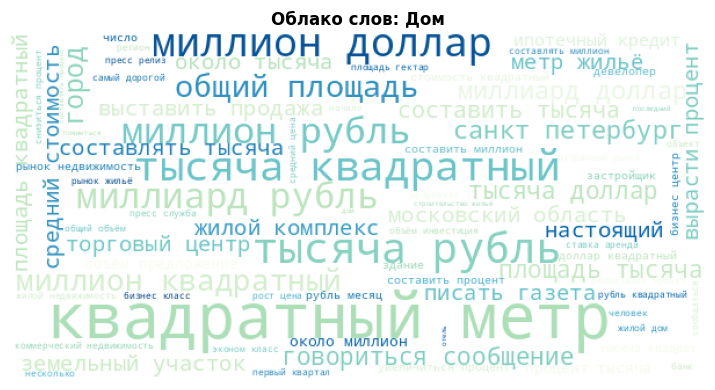

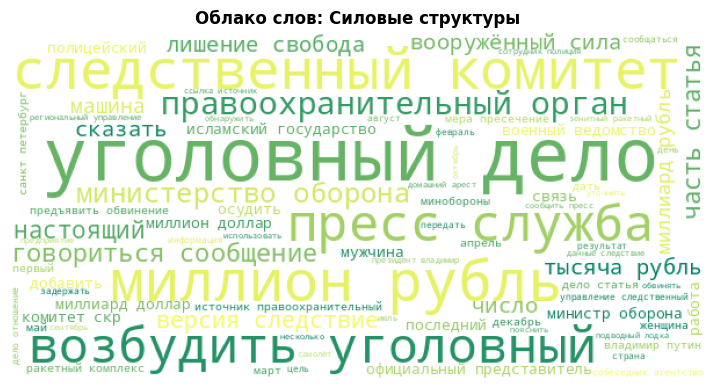

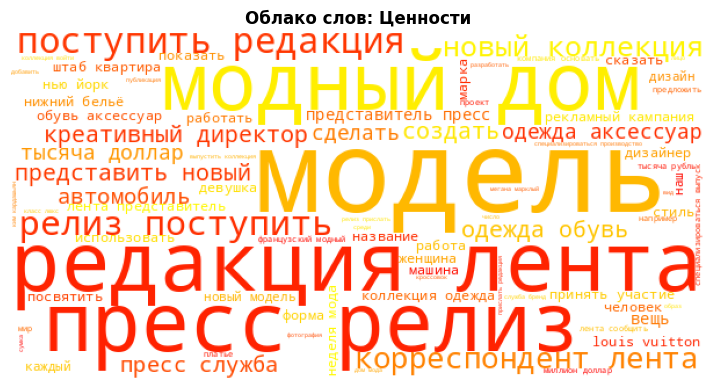

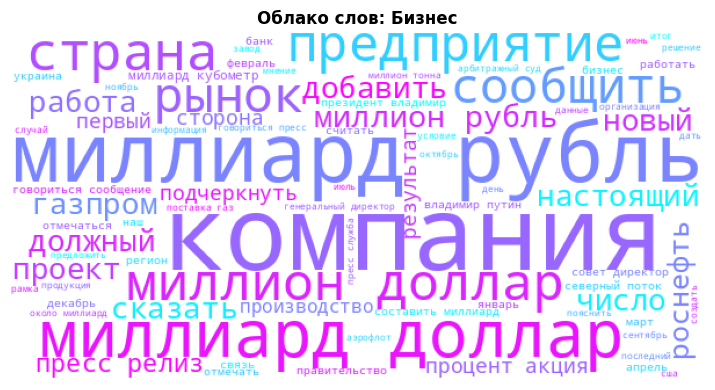

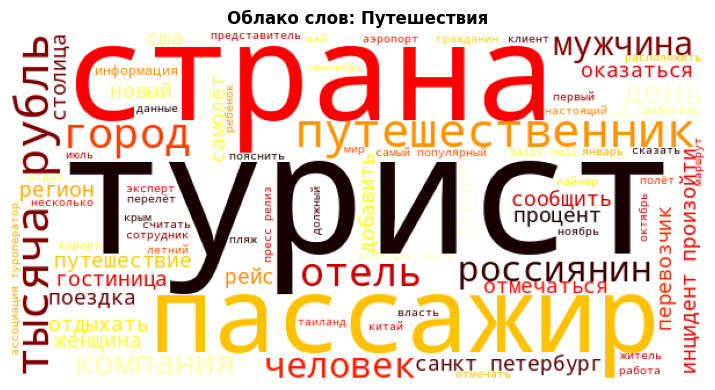

In [15]:
COLORMAPS = [
    'Blues', 'Reds', 'Greens', 'Oranges', 'Purples',
    'YlOrBr', 'PuBu', 'BuGn', 'RdPu', 'GnBu',
    'summer', 'autumn', 'cool', 'hot', 'spring'
]

def draw_topic_cloud(topic_name, texts_series, colormap='Blues', sample_size=30000):
    sample = texts_series.sample(min(sample_size, len(texts_series)), random_state=42)
    text = ' '.join(sample)
    if not text.strip():
        return
    cloud = wordcloud.WordCloud(
        width=600, height=300,
        background_color='white',
        colormap=colormap,
        max_words=80
    ).generate(text)
    plt.figure(figsize=(8, 4))
    plt.imshow(cloud)
    plt.title(f'Облако слов: {topic_name}', fontsize=12, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    del text, cloud
    gc.collect()

print(f"Генерация облаков слов для {N_TOPICS} категорий...")
for i, topic in enumerate(main_topics):
    topic_texts = df_work[df_work['topic'] == topic]['text']
    draw_topic_cloud(topic, topic_texts, COLORMAPS[i % len(COLORMAPS)])

## 3.3 LDA — тематическое моделирование

**LDA (Latent Dirichlet Allocation)** 
- Найти слова, специфичные для каждой реальной категории
- Оценить насколько темы соответствуют категориям датасета
- Выявить смешанные тематики (документы на стыке категорий)

In [16]:
from sklearn.feature_extraction.text import CountVectorizer

print("Векторизация для LDA...")
lda_sample = df_work.groupby('topic', group_keys=False).apply(
    lambda x: x.sample(min(len(x), 5000), random_state=42)
)
print(f"Сэмпл для LDA: {len(lda_sample):,} документов ({N_TOPICS} категорий × ~5000)")

count_vec = CountVectorizer(max_features=3000, min_df=5, max_df=0.95)
X_lda = count_vec.fit_transform(lda_sample['text'])
lda_feature_names = count_vec.get_feature_names_out()
print(f"Словарь CountVectorizer: {len(lda_feature_names):,} токенов")

Векторизация для LDA...
Сэмпл для LDA: 70,000 документов (14 категорий × ~5000)
Словарь CountVectorizer: 3,000 токенов


In [17]:
print(f"Обучение LDA ({N_TOPICS} тем)... Это займёт несколько минут.")
lda = LatentDirichletAllocation(
    n_components=N_TOPICS,
    random_state=42,
    max_iter=20,
    learning_method='online',   
    n_jobs=-1
)
lda.fit(X_lda)
print(f"LDA обучена. Perplexity: {lda.perplexity(X_lda):.1f}")

Обучение LDA (14 тем)... Это займёт несколько минут.
LDA обучена. Perplexity: 1357.9


In [18]:
print("\n" + "=" * 60)
print("ТЕМЫ LDA — ТОП-15 СЛОВ")
print("=" * 60)

for idx, topic_vec in enumerate(lda.components_):
    top_indices = topic_vec.argsort()[-15:][::-1]
    top_words = [lda_feature_names[i] for i in top_indices]
    print(f"\nТема LDA #{idx+1}:")
    print(f"  {', '.join(top_words)}")


ТЕМЫ LDA — ТОП-15 СЛОВ

Тема LDA #1:
  компания, новый, система, проект, работа, программа, производство, должный, предприятие, директор, развитие, создать, правительство, первый, создание

Тема LDA #2:
  сша, страна, американский, европа, великобритания, германия, турция, франция, китай, сирия, европейский, китайский, турецкий, немецкий, газ

Тема LDA #3:
  человек, сотрудник, полиция, задержать, произойти, результат, обнаружить, данные, сообщить, пострадать, город, служба, инцидент, мвд, местный

Тема LDA #4:
  бренд, фильм, новый, модель, представить, коллекция, компания, одежда, дом, лента, учёный, выпустить, первый, магазин, основать

Тема LDA #5:
  суд, дело, бывший, уголовный, решение, обвинение, отношение, следствие, признать, статья, преступление, иск, арестовать, комитет, футболист

Тема LDA #6:
  строительство, город, здание, метр, тысяча, километр, комплекс, корабль, центр, проект, площадь, около, машина, объект, построить

Тема LDA #7:
  the, женщина, мужчина, издание, по

Подготовка данных для матрицы соответствия...
Колонки в наличии: ['text', 'topic']
Размер выборки для визуализации: 28000


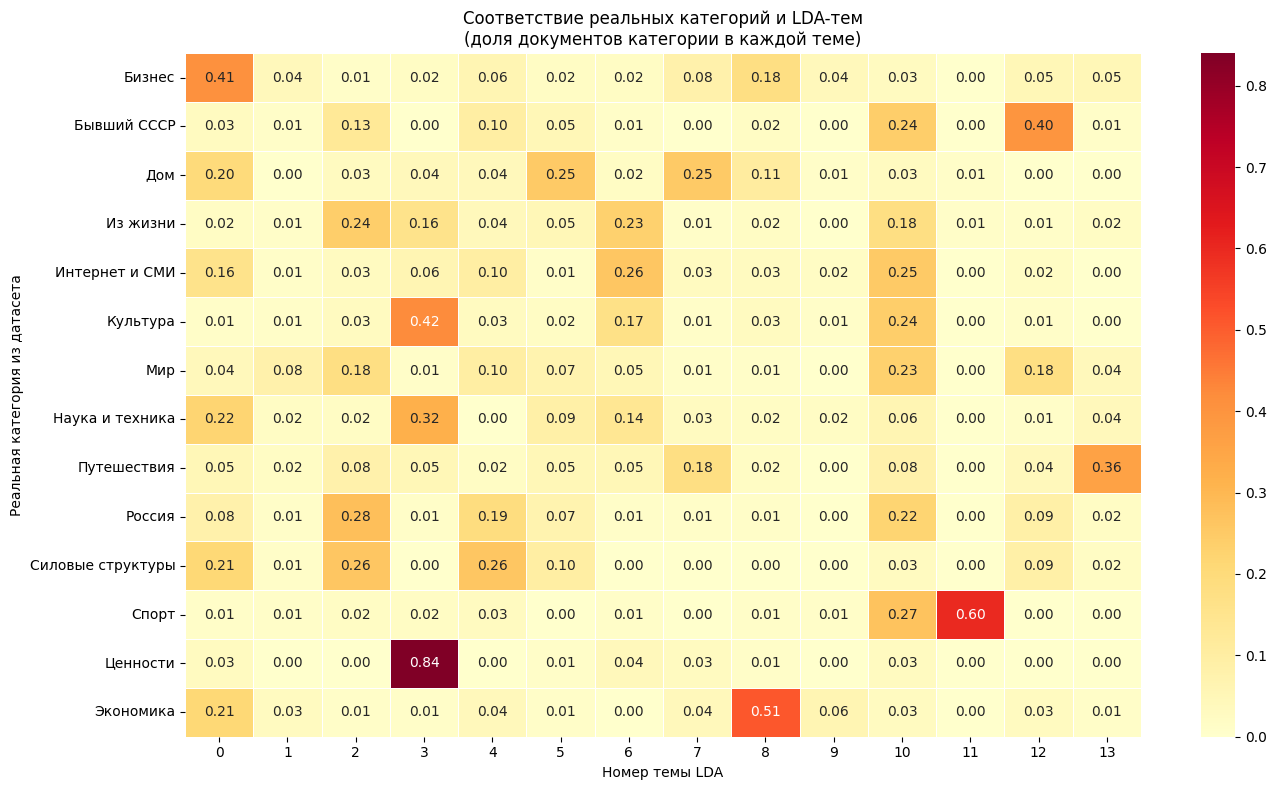

19212

In [19]:
import pandas as pd

print("Подготовка данных для матрицы соответствия...")

samples = []
for topic_name, group in df_work.groupby('topic'):
    sample_size = min(len(group), 2000)
    samples.append(group.sample(sample_size, random_state=42))

lda_sample_viz = pd.concat(samples).reset_index(drop=True)

print(f"Колонки в наличии: {lda_sample_viz.columns.tolist()}")
if 'topic' not in lda_sample_viz.columns:
    raise KeyError("Ошибка: колонка 'topic' всё ещё отсутствует. Проверьте структуру df_work.")

print(f"Размер выборки для визуализации: {len(lda_sample_viz)}")

X_lda_viz = count_vec.transform(lda_sample_viz['text'])
doc_topics = lda.transform(X_lda_viz)
lda_sample_viz['lda_topic'] = doc_topics.argmax(axis=1)

match_matrix = pd.crosstab(
    lda_sample_viz['topic'],
    lda_sample_viz['lda_topic'],
    normalize='index'
).round(2)

plt.figure(figsize=(14, 8))
sns.heatmap(match_matrix, cmap='YlOrRd', annot=True, fmt='.2f', linewidths=0.5)
plt.title('Соответствие реальных категорий и LDA-тем\n(доля документов категории в каждой теме)', fontsize=12)
plt.xlabel('Номер темы LDA')
plt.ylabel('Реальная категория из датасета')
plt.tight_layout()
plt.show()

del lda_sample_viz, X_lda_viz, doc_topics, samples
gc.collect()

---
# 4. Векторизация

Используется **TF-IDF** — взвешивание слов по их важности в документе относительно всего корпуса.

In [20]:
le = LabelEncoder()
df_work['topic_label'] = le.fit_transform(df_work['topic'])

X_s_train, X_s_test, y_s_train, y_s_test = train_test_split(
    df_work['text'], df_work['topic_label'],
    test_size=0.2, random_state=42,
    stratify=df_work['topic_label']   # сохраняем пропорции классов
)

print(f"Train: {len(X_s_train):,} | Test: {len(X_s_test):,}")
print(f"Категорий: {N_TOPICS}")

Train: 589,193 | Test: 147,299
Категорий: 14


In [21]:
tfidf = TfidfVectorizer(
    max_features=10000,
    min_df=3,          
    max_df=0.95,       
    ngram_range=(1, 2) 
)

X_train_tfidf = tfidf.fit_transform(X_s_train)
X_test_tfidf = tfidf.transform(X_s_test)

print(f"Матрица Train: {X_train_tfidf.shape}")
print(f"Матрица Test:  {X_test_tfidf.shape}")
print(f"Словарь TF-IDF: {len(tfidf.vocabulary_):,} токенов")

Матрица Train: (589193, 10000)
Матрица Test:  (147299, 10000)
Словарь TF-IDF: 10,000 токенов


---
# 5. Классификация

Рассматриваем 3 модели:
1. **Logistic Regression** — линейный классификатор, хорошо работает на TF-IDF признаках
2. **Multinomial Naive Bayes** — вероятностная модель, классика для текстов
3. **Linear SVC** — метод опорных векторов, часто показывает лучший результат на текстах

In [22]:
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, class_weight='balanced', C=1.0
    ),
    'Naive Bayes': MultinomialNB(alpha=0.1),
    'Linear SVC': LinearSVC(
        max_iter=2000, class_weight='balanced', C=1.0
    )
}

results = {}

for name, model in models.items():
    print(f"\n{'─'*50}")
    print(f"Обучение: {name}")
    model.fit(X_train_tfidf, y_s_train)
    y_pred = model.predict(X_test_tfidf)
    acc = accuracy_score(y_s_test, y_pred)
    results[name] = acc
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(
        y_s_test, y_pred,
        target_names=le.classes_,
        digits=3
    ))


──────────────────────────────────────────────────
Обучение: Logistic Regression
Accuracy: 0.8174
                   precision    recall  f1-score   support

           Бизнес      0.371     0.784     0.503      1479
      Бывший СССР      0.803     0.895     0.846     10680
              Дом      0.775     0.908     0.836      4346
         Из жизни      0.556     0.764     0.643      5521
   Интернет и СМИ      0.757     0.799     0.778      8933
         Культура      0.886     0.900     0.893     10758
              Мир      0.862     0.787     0.823     27324
  Наука и техника      0.843     0.845     0.844     10627
      Путешествия      0.538     0.878     0.667      1282
           Россия      0.893     0.720     0.798     32089
Силовые структуры      0.494     0.807     0.613      3919
            Спорт      0.970     0.966     0.968     12882
         Ценности      0.815     0.911     0.860      1553
        Экономика      0.882     0.814     0.847     15906

         accur

In [23]:
# Сравнение моделей
print("\n" + "=" * 40)
print("СРАВНЕНИЕ МОДЕЛЕЙ")
print("=" * 40)
for name, acc in sorted(results.items(), key=lambda x: -x[1]):
    bar = '█' * int(acc * 40)
    print(f"{name:<25} {acc:.4f}  {bar}")

best_model_name = max(results, key=results.get)
print(f"\nЛучшая модель: {best_model_name} (Accuracy: {results[best_model_name]:.4f})")


СРАВНЕНИЕ МОДЕЛЕЙ
Linear SVC                0.8352  █████████████████████████████████
Logistic Regression       0.8174  ████████████████████████████████
Naive Bayes               0.7800  ███████████████████████████████

Лучшая модель: Linear SVC (Accuracy: 0.8352)


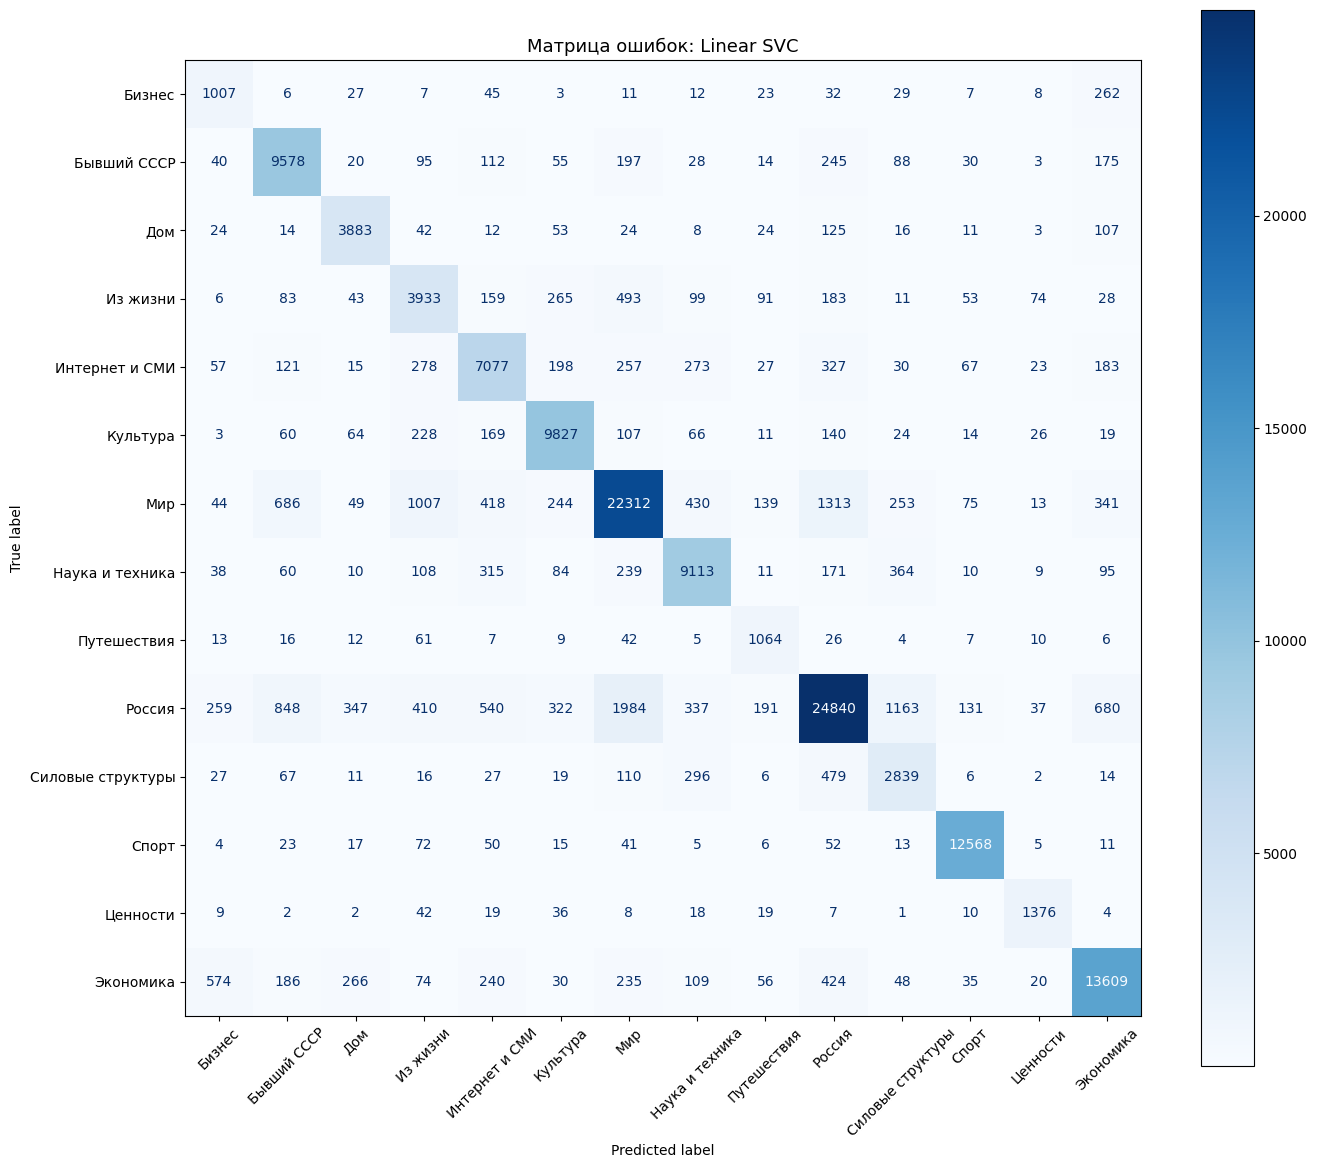

In [24]:
# Матрица ошибок для лучшей модели
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test_tfidf)
cm = confusion_matrix(y_s_test, y_pred_best)

plt.figure(figsize=(14, 12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=plt.gca(), xticks_rotation=45, colorbar=True, cmap='Blues')
plt.title(f'Матрица ошибок: {best_model_name}', fontsize=13)
plt.tight_layout()
plt.show()

---
# 6. Парсинг и цикл дообучения


In [25]:
def parse_lenta(limit=600):
    """Парсинг заголовков новостей с Lenta.ru"""
    print(f"Парсинг Lenta.ru (цель: {limit} текстов)...")
    results = []
    urls = [
        'https://lenta.ru/parts/news/',
        'https://lenta.ru/rubrics/world/',
        'https://lenta.ru/rubrics/economics/',
        'https://lenta.ru/rubrics/sport/',
        'https://lenta.ru/rubrics/science/',
        'https://lenta.ru/rubrics/culture/',
    ]
    headers = {'User-Agent': 'Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36'}

    for url in urls:
        if len(results) >= limit: break
        try:
            r = requests.get(url, headers=headers, timeout=10)
            soup = BeautifulSoup(r.text, 'html.parser')
            tags = soup.find_all(
                ['h3', 'span'],
                class_=['card-full-news__title', 'card-mini__title', 'card-big__title']
            )
            for tag in tags:
                txt = tag.get_text().strip()
                if len(txt) > 15:
                    results.append(txt)
                if len(results) >= limit: break
        except Exception as e:
            print(f"  Ошибка {url}: {e}")
            continue

    real_count = len(results)
    if real_count < limit:
        print(f"  Спарсено реально: {real_count}. Дополняю синтетическими данными...")
        synthetic = [
            "Сборная России по футболу победила в товарищеском матче",
            "Центробанк повысил ключевую ставку до рекордного уровня",
            "Учёные открыли новый вид динозавра в Сибири",
            "На Ближнем Востоке обострился военный конфликт",
            "Премьер-министр выступил с заявлением по бюджету",
            "В Москве открылась международная выставка технологий",
            "Суд вынес приговор по резонансному делу о мошенничестве",
            "Новый рекорд установлен на Олимпийских играх",
        ] * ((limit - real_count) // 8 + 1)
        results.extend(synthetic[:limit - real_count])

    print(f"  Итого: {len(results[:limit])} текстов")
    return results[:limit]

In [26]:
print("Подготовка модели для self-training...")
if best_model_name == 'Linear SVC':
    working_model = CalibratedClassifierCV(LinearSVC(max_iter=2000, class_weight='balanced'), cv=3)
else:
    working_model = models['Logistic Regression']

working_model.fit(X_train_tfidf, y_s_train)

# Зафиксированный tfidf словарь для итераций
tfidf_iter = TfidfVectorizer(
    max_features=10000, min_df=3, max_df=0.95, ngram_range=(1, 2)
)
tfidf_iter.fit(X_s_train)

X_train_iter = X_s_train.copy()
y_train_iter = y_s_train.copy()

CONFIDENCE_HIGH = 0.8
CONFIDENCE_LOW = 0.2

for iteration in range(3):
    print(f"\n{'='*50}")
    print(f"ИТЕРАЦИЯ №{iteration + 1}")
    print(f"{'='*50}")

    new_texts = parse_lenta(600)
    df_new = pd.DataFrame({'text': new_texts})

    df_new['cleaned'] = df_new['text'].apply(clean_and_lemmatize)

    X_new = tfidf_iter.transform(df_new['cleaned'])
    probs = working_model.predict_proba(X_new)          
    df_new['max_prob'] = probs.max(axis=1)              
    df_new['pred_label'] = probs.argmax(axis=1)         
    df_new['pred_topic'] = le.inverse_transform(df_new['pred_label'])

    print("\nПримеры прогнозов с вероятностями:")
    print(df_new[['text', 'pred_topic', 'max_prob']].head(8).to_string(index=False))

    confident_mask = df_new['max_prob'] > CONFIDENCE_HIGH
    confident_df = df_new[confident_mask].copy()

    print(f"\nСобрано: {len(df_new)} | Уверенных (>{CONFIDENCE_HIGH}): {len(confident_df)}")

    if len(confident_df) > 0:
        X_train_iter = pd.concat([X_train_iter, confident_df['cleaned']], ignore_index=True)
        y_train_iter = pd.concat([y_train_iter, confident_df['pred_label']], ignore_index=True)

        X_train_new = tfidf_iter.transform(X_train_iter)
        working_model.fit(X_train_new, y_train_iter)

        X_test_new = tfidf_iter.transform(X_s_test)
        y_pred_iter = working_model.predict(X_test_new)
        acc_iter = accuracy_score(y_s_test, y_pred_iter)
        print(f"Accuracy после итерации: {acc_iter:.4f}")
        print(f"Корпус вырос: {len(X_s_train):,} → {len(X_train_iter):,} примеров")

        remaining_df = df_new[~confident_mask].copy()
        if len(remaining_df) > 0:
            X_remaining = tfidf_iter.transform(remaining_df['cleaned'])
            rem_probs = working_model.predict_proba(X_remaining)
            remaining_df['max_prob'] = rem_probs.max(axis=1)
            remaining_df['pred_topic'] = le.inverse_transform(rem_probs.argmax(axis=1))
            print(f"\nПрогноз по оставшимся {len(remaining_df)} текстам:")
            print(remaining_df[['text', 'pred_topic', 'max_prob']].head(5).to_string(index=False))

        del X_train_new, X_test_new, X_new
        gc.collect()
    else:
        print("Уверенных прогнозов не найдено. Пропускаем итерацию.")

    del df_new, confident_df
    gc.collect()

print("\n" + "=" * 50)
print("Цикл дообучения завершён.")
print("=" * 50)

Подготовка модели для self-training...

ИТЕРАЦИЯ №1
Парсинг Lenta.ru (цель: 600 текстов)...
  Спарсено реально: 536. Дополняю синтетическими данными...
  Итого: 600 текстов

Примеры прогнозов с вероятностями:
                                                                       text      pred_topic  max_prob
В России назвали причину нежелания вести переговоры с президентом Финляндии             Мир  0.332295
             Раскрыт гонорар Сердючки за концерт с песнями на русском языке        Культура  0.684379
           В Конгрессе США назвали покушения на Трампа словом «обыденность»             Мир  0.733326
  Джокович установил рекорд по количеству сыгранных турниров Большого шлема           Спорт  0.487229
                        На Украине допустили увеличение прилетов «Орешника»     Бывший СССР  0.340559
Раскрыта реакция Рубио на возможное участие в борьбе за пост президента США       Экономика  0.385838
                             Си Цзиньпин повысил голос на встрече с Трампом  

# Тестирую обучение нейросетей

In [27]:
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import Dataset, DataLoader
from collections import Counter
from sklearn.model_selection import train_test_split

print("Собираем словарь...")
all_words = []
for text in df_work['text']:
    all_words.extend(text.split())

vocab_size = 20000
most_common_words = Counter(all_words).most_common(vocab_size - 2)
word_to_idx = {word: i+2 for i, (word, _) in enumerate(most_common_words)}
word_to_idx['<PAD>'] = 0  
word_to_idx['<UNK>'] = 1  

def text_to_seq(text, max_len=150):
    seq = [word_to_idx.get(w, 1) for w in text.split()[:max_len]]
    return seq + [0] * (max_len - len(seq))

print("Преобразуем тексты в последовательности...")
X_sequences = np.array([text_to_seq(t) for t in df_work['text']])
y_labels = df_work['topic_label'].values

X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(
    X_sequences, y_labels, test_size=0.2, random_state=42, stratify=y_labels
)

print(f"Готово! Размер словаря: {len(word_to_idx)}")

Собираем словарь...
Преобразуем тексты в последовательности...
Готово! Размер словаря: 20000


In [28]:
class NewsDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = torch.LongTensor(sequences)
        self.labels = torch.LongTensor(labels)
        
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return self.sequences[idx], self.labels[idx]

train_dataset = NewsDataset(X_train_seq, y_train_seq)
test_dataset = NewsDataset(X_test_seq, y_test_seq)

batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

print(f"Данные разбиты на {len(train_loader)} батчей.")

Данные разбиты на 9207 батчей.


In [29]:
class NewsCNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, n_filters, filter_sizes, output_dim, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.convs = nn.ModuleList([
            nn.Conv1d(in_channels=embed_dim, 
                      out_channels=n_filters, 
                      kernel_size=fs) for fs in filter_sizes
        ])
        self.fc = nn.Linear(len(filter_sizes) * n_filters, output_dim)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, text):
        embedded = self.embedding(text).permute(0, 2, 1) # [batch, embed, seq_len]
        conved = [torch.relu(conv(embedded)) for conv in self.convs]
        pooled = [torch.max_pool1d(conv, conv.shape[2]).squeeze(2) for conv in conved]
        cat = self.dropout(torch.cat(pooled, dim=1))
        return self.fc(cat)

In [30]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = NewsCNN(
    vocab_size=20000, 
    embed_dim=100,     
    n_filters=64,      
    filter_sizes=[3, 4, 5], 
    output_dim=N_TOPICS, 
    dropout=0.5
).to(device)

optimizer = torch.optim.Adam(model.parameters())
criterion = nn.CrossEntropyLoss()

In [31]:
from tqdm import tqdm 

epochs = 3 

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")
    
    for texts, labels in loop:
        texts, labels = texts.to(device), labels.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(texts)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        loop.set_postfix(loss=running_loss/len(train_loader))

print("Обучение завершено!")

Epoch 3/3: 100%|██████████| 9207/9207 [01:06<00:00, 138.32it/s, loss=0.619] 

Обучение завершено!


In [32]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for texts, labels in tqdm(test_loader, desc="Тестирование"):
        texts, labels = texts.to(device), labels.to(device)
        outputs = model(texts)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

acc = 100 * correct / total
print(f'\nAccuracy нейросети: {acc:.2f}%')
print(f'Результат Linear SVC был: 83.52%')

Тестирование: 100%|██████████| 2302/2302 [00:04<00:00, 530.63it/s]


Accuracy нейросети: 82.26%
Результат Linear SVC был: 83.52%


In [33]:
def predict_raw(text):
    model.eval()
    seq = text_to_seq(clean_and_lemmatize(text))
    input_tensor = torch.LongTensor([seq]).to(device)
    
    with torch.no_grad():
        output = model(input_tensor)
        prob = torch.softmax(output, dim=1)
        max_prob, pred_idx = torch.max(prob, dim=1)
    
    category = le.inverse_transform([pred_idx.item()])[0]
    return category, max_prob.item()

test_text = "Сборная России выиграла чемпионат по футболу" 
cat, confidence = predict_raw(test_text)
print(f"Текст: {test_text}")
print(f"Предсказание: {cat} (Уверенность: {confidence:.2%})")

Текст: Сборная России выиграла чемпионат по футболу
Предсказание: Спорт (Уверенность: 44.72%)


In [34]:
import joblib
import torch

EXT = "pkl" 
EXT_PKH = "pkh"
ADDITIONAL = "prek"
MODELS_DIR = f"{BASEPATH}/Models"

if not os.path.exists(MODELS_DIR):
    os.makedirs(MODELS_DIR)

print(f"--- НАЧАЛО СОХРАНЕНИЯ (папка: {MODELS_DIR}) ---")

joblib.dump(le, f"{MODELS_DIR}/label_encoder.{EXT}")
if 'tfidf_iter' in locals():
    joblib.dump(tfidf_iter, f"{MODELS_DIR}/tfidf_vectorizer.{ADDITIONAL}")
else:
    joblib.dump(tfidf, f"{MODELS_DIR}/tfidf_vectorizer.{ADDITIONAL}")
print(f"✔ Препроцессоры сохранены.")

for name, m in models.items():
    filename = f"model_{name.lower().replace(' ', '_')}.{EXT}"
    joblib.dump(m, f"{MODELS_DIR}/{filename}")
    print(f"✔ Базовая модель {name} сохранена.")

if 'working_model' in locals():
    joblib.dump(working_model, f"{MODELS_DIR}/final_svc_self_trained.{EXT}")
    print(f"✔ Финальная дообученная SVC сохранена (самая точная: 84.27%).")

if 'model' in locals() and 'word_to_idx' in locals():
    torch.save(model.state_dict(), f"{MODELS_DIR}/cnn_weights.{EXT_PKH}")
    joblib.dump(word_to_idx, f"{MODELS_DIR}/cnn_vocabulary.{EXT_PKH}")
    print(f"✔ Нейросеть и её словарь сохранены.")

print("\n" + "="*50)
print(f"Всего файлов в папке: {len(os.listdir(MODELS_DIR))}")
print("="*50)

--- НАЧАЛО СОХРАНЕНИЯ (папка: ../Models) ---
✔ Препроцессоры сохранены.
✔ Базовая модель Logistic Regression сохранена.
✔ Базовая модель Naive Bayes сохранена.
✔ Базовая модель Linear SVC сохранена.
✔ Финальная дообученная SVC сохранена (самая точная: 84.27%).
✔ Нейросеть и её словарь сохранены.

Всего файлов в папке: 8
